In [3]:
# analyse different systems with the same spectral radius and see how the vector orthogonal to the subspace develops

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pickle

from sf_workingdir_lilly.dmlab.analysis.custom_esn_analysis import get_hidden_states_iso_feat, len_new_orth_vec, len_new_orth_vec_new_not_norm, get_time_of_threshold_crossing, exp_func, stable_trials, get_time_of_norm_threshold_crossing


In [3]:
spec_rad = 1.4
time_steps = 70

Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
#trial=6
fixed_whh=True
fixed_wih=True

x_vals = np.arange(1,70)

In [6]:
x_vals = np.arange(1,70)
#fig, ax = plt.subplots(10,5, figsize=(25,50), sharey=True, sharex=True)

orth_vec_lens = np.zeros((50, Hippo_n_feature, time_steps-1))

for t in range(50):
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, t, fixed_whh, fixed_wih, input_idx=i)
        try:
            len_orth_vectors = len_new_orth_vec(hs, time_steps)
            #ax[t//5, t%5].scatter(x_vals, len_orth_vectors, label=f'{i}', s=5)
            orth_vec_lens[t, i, :] = len_orth_vectors
        except Exception as e:
            print(f'Could not compute length of orthogonal vectors for trial {t} and input neuron {i}: {e}')
            pass
        #ax[t//5, t%5].set_title(f'{t}')

Could not compute length of orthogonal vectors for trial 24 and input neuron 5: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 1).
Could not compute length of orthogonal vectors for trial 38 and input neuron 6: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 1).


In [7]:
orth_vec_lens_not_norm = np.zeros((50, Hippo_n_feature, time_steps-1))

for t in range(50):
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, t, fixed_whh, fixed_wih, input_idx=i)
        try:
            len_orth_vectors = len_new_orth_vec_new_not_norm(hs, time_steps)
            #ax[t//5, t%5].scatter(x_vals, len_orth_vectors, label=f'{i}', s=5)
            orth_vec_lens_not_norm[t, i, :] = len_orth_vectors
        except Exception as e:
            print(f'Could not compute length of orthogonal vectors for trial {t} and input neuron {i}: {e}')
            pass

Could not compute length of orthogonal vectors for trial 46 and input neuron 10: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 1).


In [8]:
thresh_crossed = get_time_of_threshold_crossing(orth_vec_lens)
print(thresh_crossed)

thresh_crossed_not_norm = get_time_of_threshold_crossing(orth_vec_lens_not_norm)
print(thresh_crossed_not_norm)

#thresh_crossed_not_norm = get_time_of_threshold_crossing(orth_vec_lens_not_norm, threshold=0.005)
#print(thresh_crossed_not_norm)

[12. 28. 20. 27. 27. 20. 18. 18. 39. 28. 12. 28. 27. 14. 50. 26. 10. 25.
 30. 14. 13. 11. 29. 50. 15. 15. 10. 14. 17. 12. 13.  9. 12. 24.  9. 21.
 17. 11. 26. 50. 23. 20. 14. 19. 15. 41. 18. 15. 12. 21.]
[12. 11. 14.  8. 12. 12.  9.  9.  9.  8. 14.  8. 15.  9.  7. 14.  9.  9.
  8. 22. 13. 26.  9.  7.  8. 25. 10.  9. 10.  9.  8. 14. 15. 16. 20. 11.
 10. 12. 13.  6.  9.  9.  8.  6. 12.  8. 18. 12. 13. 13.]


In [9]:
# fit an exponential curve to the length of the orthogonal vector over time
a_vals = np.zeros(50)
tau_vals = np.zeros(50)
y_vals = np.zeros((50, time_steps-1))
ys = orth_vec_lens.copy()

for t in range(50):
    a0 = orth_vec_lens[t, 0, 0]
    tau0 = 5.0
    popt, pcov = curve_fit(exp_func, x_vals, ys[t, 0, :], p0=[a0, tau0])
    a_fit, tau_fit = popt
    a_vals[t] = a_fit
    tau_vals[t] = tau_fit
    y_vals[t, :] = exp_func(x_vals, a_fit, tau_fit)

In [10]:
# fit an exponential curve to the length of the orthogonal vector over time
a_vals_not_norm = np.zeros(50)
tau_vals_not_norm = np.zeros(50)
y_vals_not_norm = np.zeros((50, time_steps-1))
ys_not_norm = orth_vec_lens_not_norm.copy()

for t in range(50):
    a0_not_norm = orth_vec_lens_not_norm[t, 0, 0]
    tau0_not_norm = 5.0
    popt, pcov = curve_fit(exp_func, x_vals, ys_not_norm[t, 0, :], p0=[a0_not_norm, tau0_not_norm])
    a_fit_not_norm, tau_fit_not_norm = popt
    a_vals_not_norm[t] = a_fit_not_norm
    tau_vals_not_norm[t] = tau_fit_not_norm
    y_vals_not_norm[t, :] = exp_func(x_vals, a_fit_not_norm, tau_fit_not_norm)

#print(y_vals_not_norm)

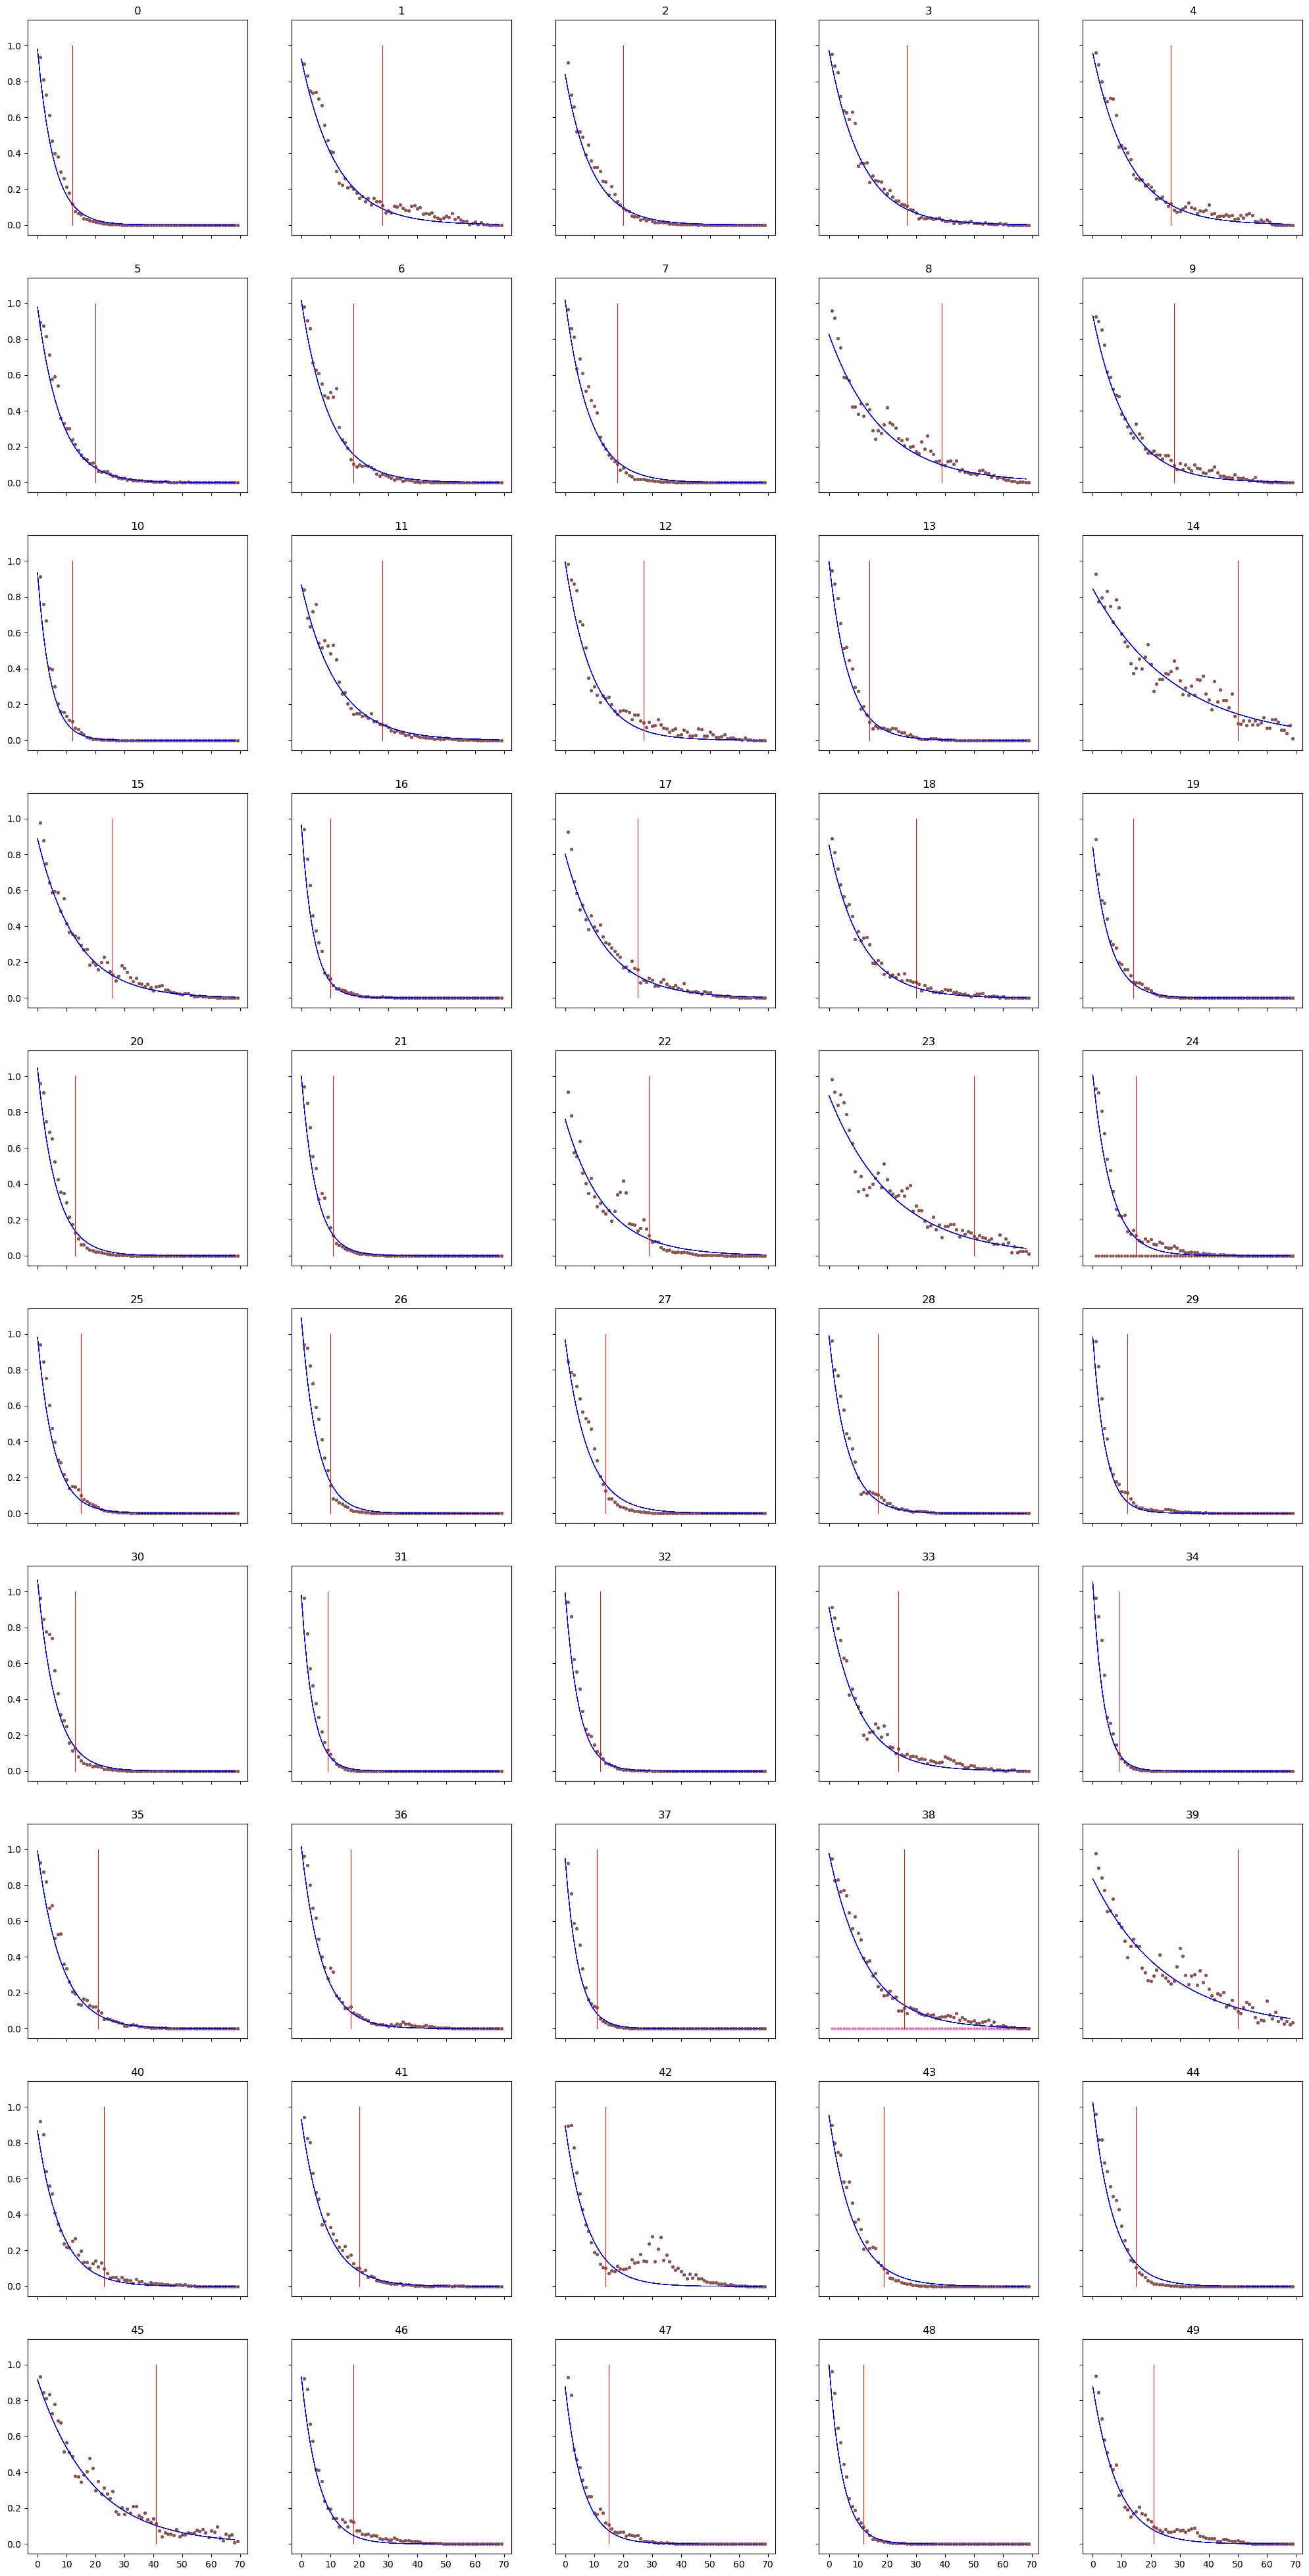

In [11]:
# plot the lengths of the orthogonal vectors
fig, ax = plt.subplots(10,5, figsize=(25,50), sharey=True, sharex=True)
for t in range(50):
    for i in range(Hippo_n_feature):
        ax[t//5, t%5].scatter(x_vals, orth_vec_lens[t, i, :], label=f'{i}', s=5)
        ax[t//5, t%5].plot(y_vals[t, :], c='b',linewidth=0.5)
        ax[t//5, t%5].set_title(f'{t}')
        ax[t//5, t%5].vlines(thresh_crossed[t], ymin=0, ymax=1, colors='r', linewidths=0.5)

### save the relevant MC measures

In [12]:
# compute the norms for all neurons over all trials
neuron_norms_for_srs = np.zeros((50, time_steps))

for t in range(50):
    #for i in range(Hippo_n_feature):
    hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, t, fixed_whh, fixed_wih, input_idx=0)
      
    neuron_norms_for_srs[t, :] = hs.norm(dim=1)
        
stable_idx = stable_trials(neuron_norms_for_srs)
stable_trials_norms = neuron_norms_for_srs[stable_idx, :]

/tmp/ipykernel_4137076/3572386476.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  neuron_norms_for_srs[t, :] = hs.norm(dim=1)


In [13]:
'''
with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/random.pkl", "wb") as f:
    pickle.dump(stable_trials_norms, f)

'''

'\nwith open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/random.pkl", "wb") as f:\n    pickle.dump(stable_trials_norms, f)\n\n'

In [14]:
# compute when the threshold was crossed for the norms for stable trials
tresh_crossed_norms = get_time_of_norm_threshold_crossing(stable_trials_norms, threshold=0.1)
print(tresh_crossed_norms)

thresh  [0.35609281 0.30070024 0.29777465 0.32939219 0.27576187 0.30135648
 0.29947381 0.2970005  0.326017   0.35539355 0.30919702 0.39074905
 0.30562704 0.39866538 0.38848724 0.35767806 0.31678853 0.39240265
 0.32274506 0.38528719 0.40006485 0.40778885 0.33952801 0.32758176
 0.36069052 0.31150663 0.4001173  0.35297537 0.34400606 0.338218
 0.36851158 0.32251027 0.36541083 0.36989548]
[15. 11. 20. 36. 11. 19. 11. 13. 12. 25. 15.  8. 24. 13. 15. 13.  8. 15.
 19. 40. 30. 21. 27. 27. 21. 19.  6. 19. 21. 18.  9. 11. 70. 29.]


In [15]:
tau_vals_stable = tau_vals[stable_idx]
tau_vals_not_norm_stable = tau_vals_not_norm[stable_idx]
print(len(tau_vals_not_norm_stable))

thresh_crossed_stable = thresh_crossed[stable_idx]
thresh_crossed_not_norm_stable = thresh_crossed_not_norm[stable_idx]

34


In [16]:
'''

mc_measures = {#'norms' : neuron_norms_for_srs,
                'tau_orth_vec': tau_vals_stable,
               'tau_orth_vec_not_norm' : tau_vals_not_norm_stable,
               'orth_vec_thresh_crossed': thresh_crossed_stable,
               'orth_vec_thresh_crossed_not_norm': thresh_crossed_not_norm_stable,
               'norm_thresh_crossed': tresh_crossed_norms
               }

with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/mc_measures1.4.pkl", "wb") as f:
    pickle.dump(mc_measures, f)

'''

'\n\nmc_measures = {#\'norms\' : neuron_norms_for_srs,\n                \'tau_orth_vec\': tau_vals_stable,\n               \'tau_orth_vec_not_norm\' : tau_vals_not_norm_stable,\n               \'orth_vec_thresh_crossed\': thresh_crossed_stable,\n               \'orth_vec_thresh_crossed_not_norm\': thresh_crossed_not_norm_stable,\n               \'norm_thresh_crossed\': tresh_crossed_norms\n               }\n\nwith open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/mc_measures1.4.pkl", "wb") as f:\n    pickle.dump(mc_measures, f)\n\n'

### continue with the plotting

In [17]:
# get the trials sorted by their tau values and threshold crossing times
idx_sorted_tau = np.argsort(-tau_vals)
idx_sorted_thresh_crossed = np.argsort(-thresh_crossed)

print(idx_sorted_tau)
#print(tau_vals[idx_sorted_tau])
print(idx_sorted_thresh_crossed)
#print(thresh_crossed[idx_sorted_thresh_crossed])

[14 39 23 45  8 22 17 15 38  4 11  1  9  3 18 33  6 12  2 49 43  7 41 35
  5 40 42 27 44 36 13 20 24 28 30 47 46 19 25  0 26 21 48 32 37 10 29 16
 31 34]
[14 23 39 45  8 18 22  9  1 11  4  3 12 38 15 17 33 40 35 49 41  2  5 43
  7  6 46 28 36 47 25 24 44 13 19 27 42 30 20  0 29 10 48 32 37 21 16 26
 31 34]


In [18]:
# see the stable trials sorted by their tau values and threshold crossing times
stable_trials_idx = stable_trials(neuron_norms_for_srs)
print(stable_trials_idx)
print('######################################')

m = np.isin(idx_sorted_tau, stable_trials_idx)
stable_sorted_tau = idx_sorted_tau[m]
print(stable_sorted_tau)

m = np.isin(idx_sorted_thresh_crossed, stable_trials_idx)
stable_sorted_thresh = idx_sorted_thresh_crossed[m]
print(stable_sorted_thresh)

[ 1  3  4  5  6  7  8  9 11 12 13 14 15 17 18 22 23 24 27 28 29 30 33 35
 36 38 39 40 41 42 43 45 47 49]
######################################
[14 39 23 45  8 22 17 15 38  4 11  1  9  3 18 33  6 12 49 43  7 41 35  5
 40 42 27 36 13 24 28 30 47 29]
[14 23 39 45  8 18 22  9  1 11  4  3 12 38 15 17 33 40 35 49 41  5 43  7
  6 28 36 47 24 13 27 42 30 29]


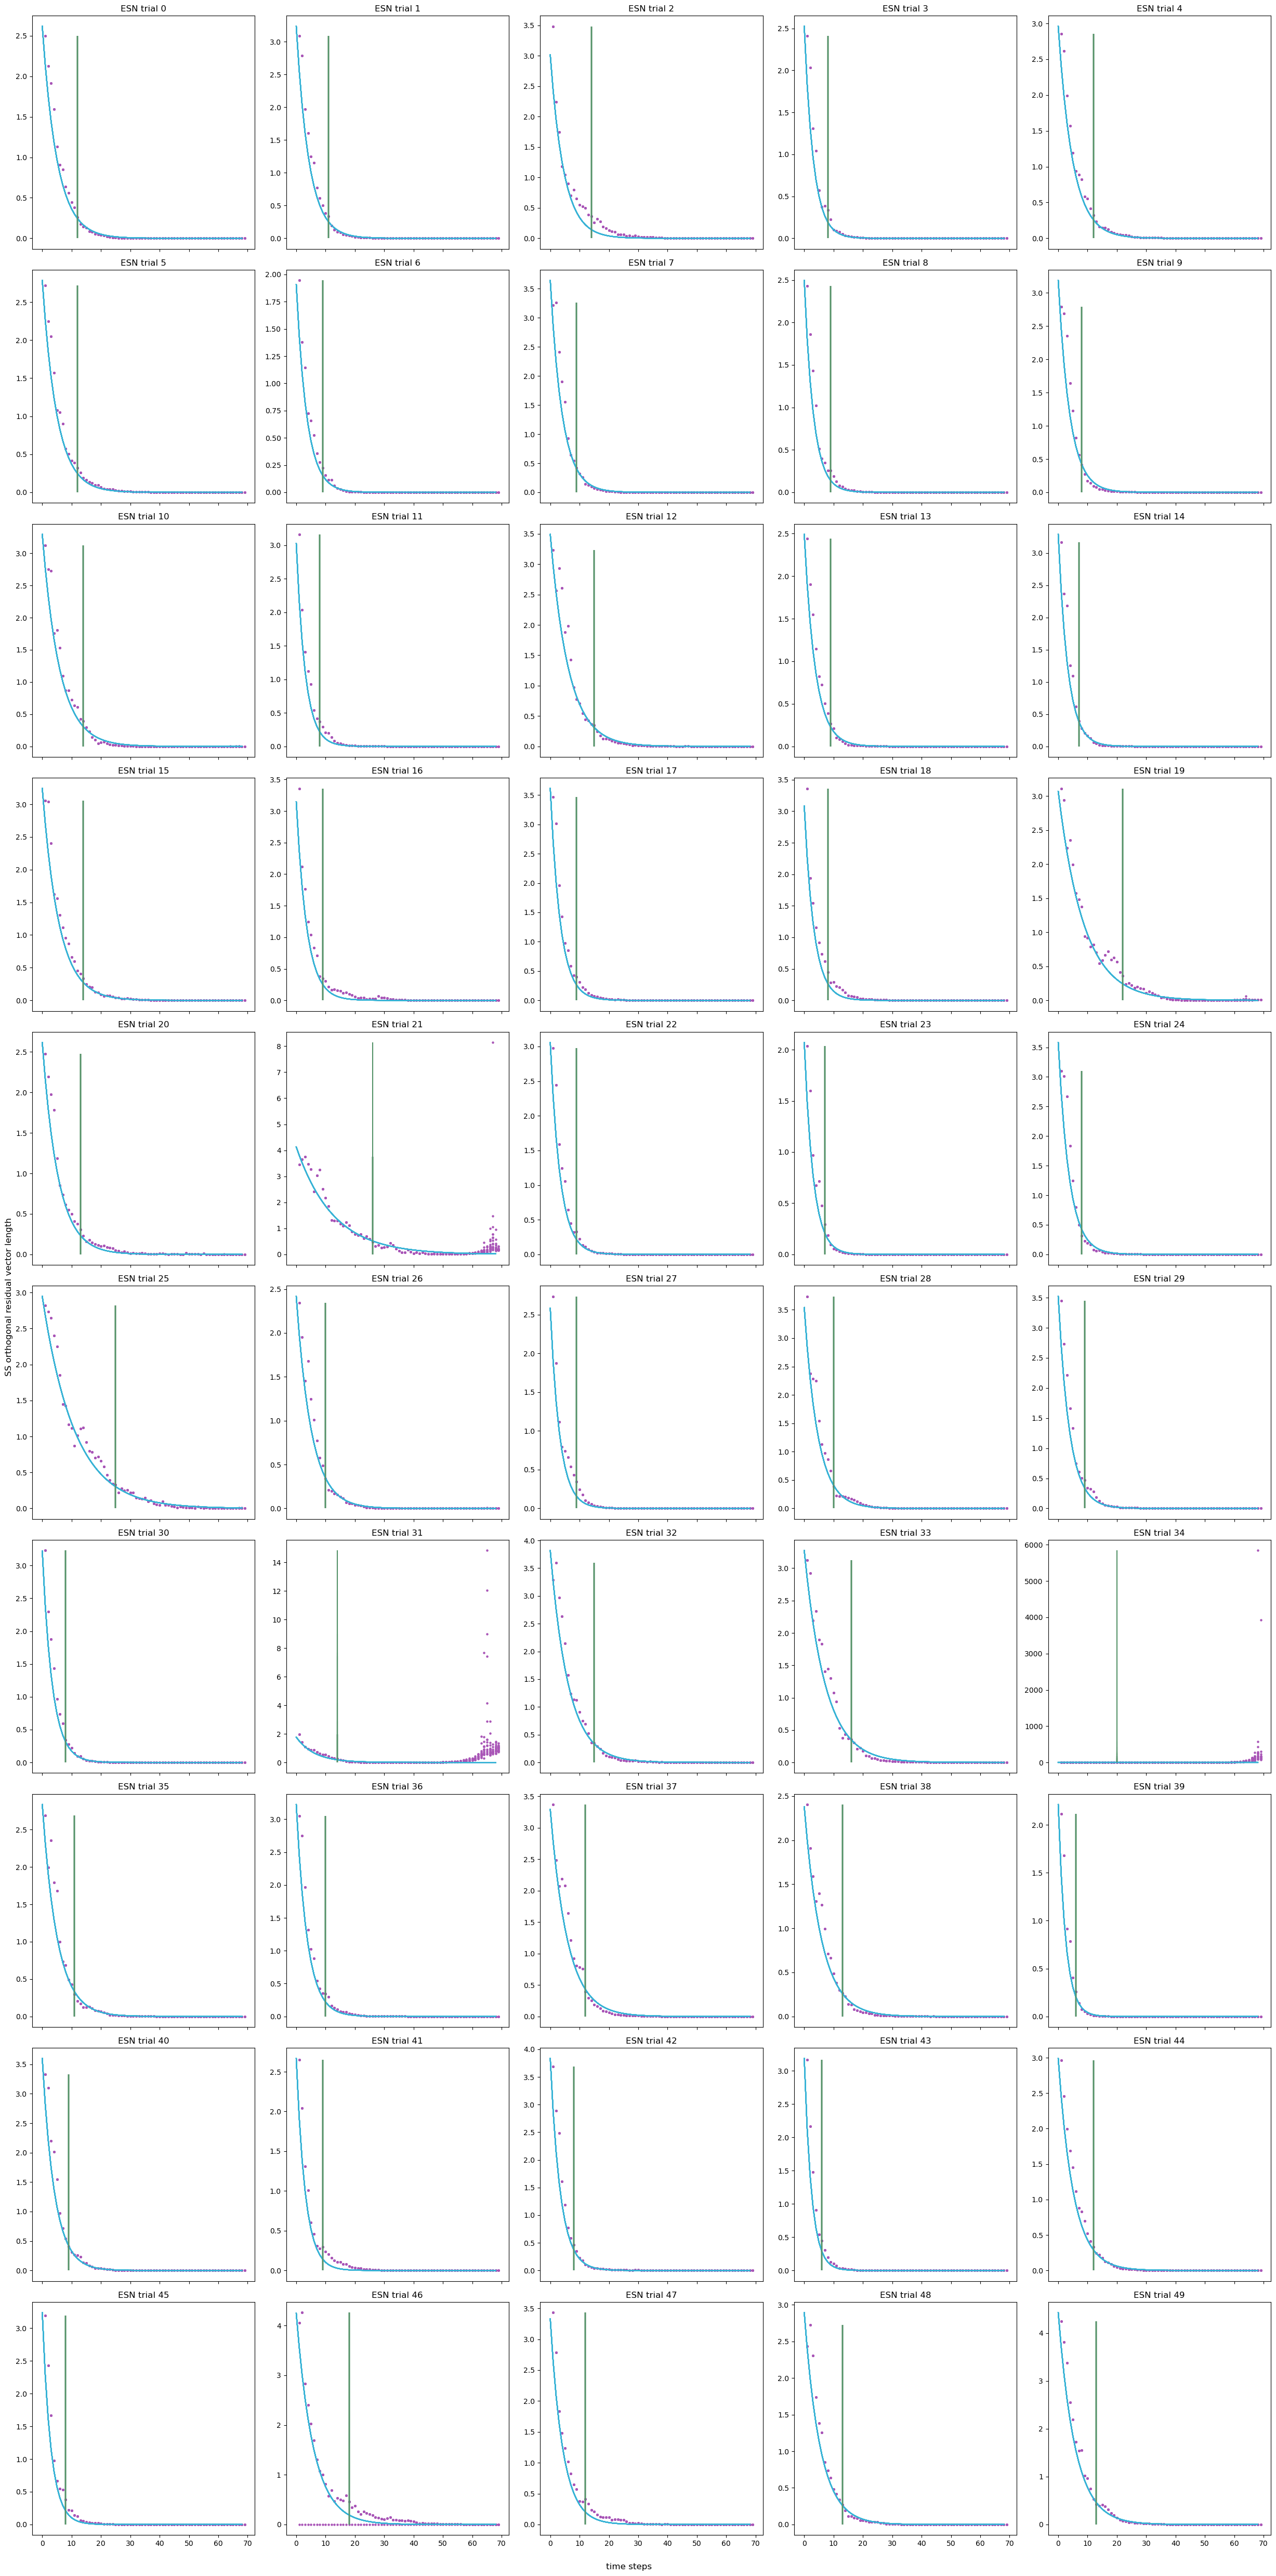

In [19]:
# plot the lengths of the orthogonal vectors but the new vector was not normalized when computing the orthogonal vector
fig, ax = plt.subplots(10,5, figsize=(25,50), sharex=True)
for t in range(50):
    for i in range(Hippo_n_feature):
        ax[t//5, t%5].scatter(x_vals, orth_vec_lens_not_norm[t, i, :], label=f'{i}', s=5, c='#a956b7')
        ax[t//5, t%5].plot(y_vals_not_norm[t, :], c="#37B3D6")
        ax[t//5, t%5].set_title(f'ESN trial {t}')
        ax[t//5, t%5].vlines(thresh_crossed_not_norm[t], ymin=0, ymax=max(orth_vec_lens_not_norm[t, i, :]), colors="#549268")

fig.supxlabel("time steps")
fig.supylabel("SS orthogonal residual vector length")
fig.tight_layout(rect=[0.01, 0.01, 1, 1])

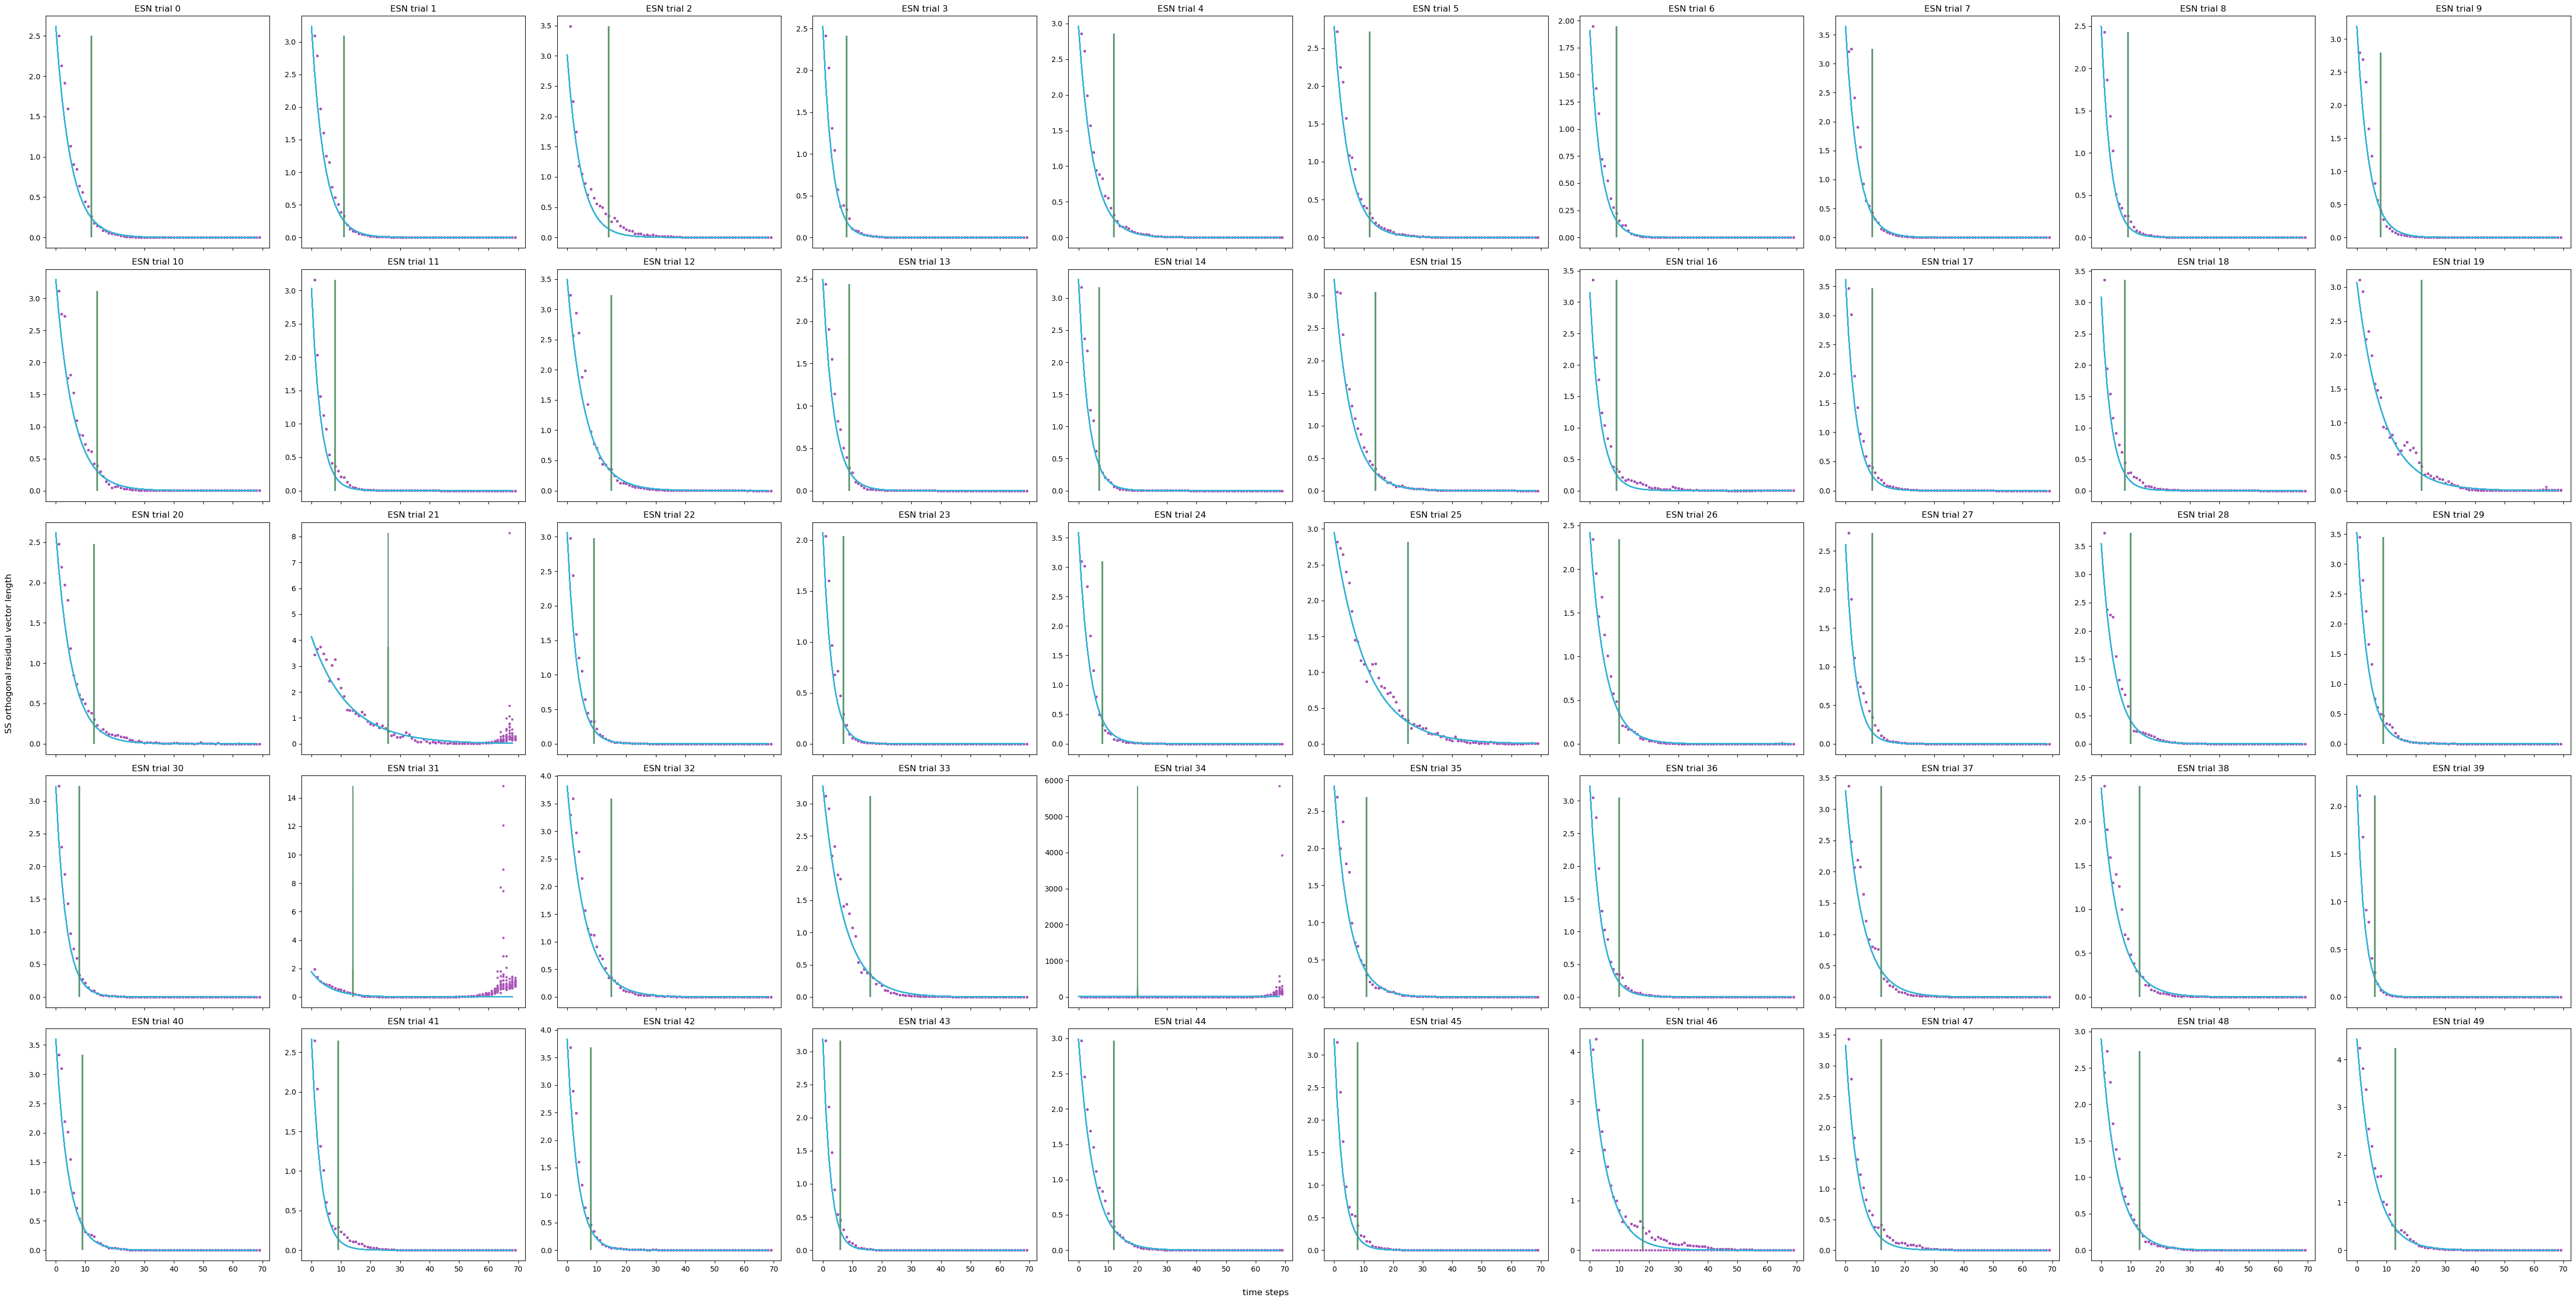

In [28]:
fig, ax = plt.subplots(5,10, figsize=(50,25), sharex=True)
for t in range(50):
    for i in range(Hippo_n_feature):
        ax[t//10, t%10].scatter(x_vals, orth_vec_lens_not_norm[t, i, :], label=f'{i}', s=5, c='#a956b7')
        ax[t//10, t%10].plot(y_vals_not_norm[t, :], c="#37B3D6")
        ax[t//10, t%10].set_title(f'ESN trial {t}')
        ax[t//10, t%10].vlines(thresh_crossed_not_norm[t], ymin=0, ymax=max(orth_vec_lens_not_norm[t, i, :]), colors="#549268")

fig.supxlabel("time steps")
fig.supylabel("SS orthogonal residual vector length")
fig.tight_layout(rect=[0.02, 0.01, 1, 1])

In [21]:
# get the trials sorted by their tau values and threshold crossing times
idx_sorted_tau_not_norm = np.argsort(-tau_vals_not_norm)
idx_sorted_thresh_crossed_not_norm = np.argsort(-thresh_crossed_not_norm)

print(idx_sorted_tau_not_norm)
#print(tau_vals[idx_sorted_tau])
print(idx_sorted_thresh_crossed_not_norm)
#print(thresh_crossed[idx_sorted_thresh_crossed])

[34 21 25 19 33 31 12 32 10 37 38 46 49 15 48 20 44 26 35  0  5  4 28  2
  1 47 40  7  9 29 13 24 36  6 16 42 17 30 22 18 14 27  8  3 41 23 11 45
 39 43]
[21 25 19 34 46 33 32 12 31  2 10 15 20 49 48 38 37  5  4  0 47 44  1 35
 36 28 26 22 29 27 17 13 16  7  6  8 41 40 11 24  3  9 18 30 45 42 23 14
 43 39]


In [22]:
# see the stable trials sorted by their tau values and threshold crossing times
stable_trials_idx_not_norm = stable_trials(neuron_norms_for_srs)
print(stable_trials_idx_not_norm)
print('######################################')

m_not_norm = np.isin(idx_sorted_tau_not_norm, stable_trials_idx_not_norm)
stable_sorted_tau_not_norm = idx_sorted_tau_not_norm[m_not_norm]
print(stable_sorted_tau_not_norm)

m_not_norm = np.isin(idx_sorted_thresh_crossed_not_norm, stable_trials_idx_not_norm)
stable_sorted_thresh_not_norm = idx_sorted_thresh_crossed_not_norm[m_not_norm]
print(stable_sorted_thresh_not_norm)

[ 1  3  4  5  6  7  8  9 11 12 13 14 15 17 18 22 23 24 27 28 29 30 33 35
 36 38 39 40 41 42 43 45 47 49]
######################################
[33 12 38 49 15 35  5  4 28  1 47 40  7  9 29 13 24 36  6 42 17 30 22 18
 14 27  8  3 41 23 11 45 39 43]
[33 12 15 49 38  5  4 47  1 35 36 28 22 29 27 17 13  7  6  8 41 40 11 24
  3  9 18 30 45 42 23 14 43 39]


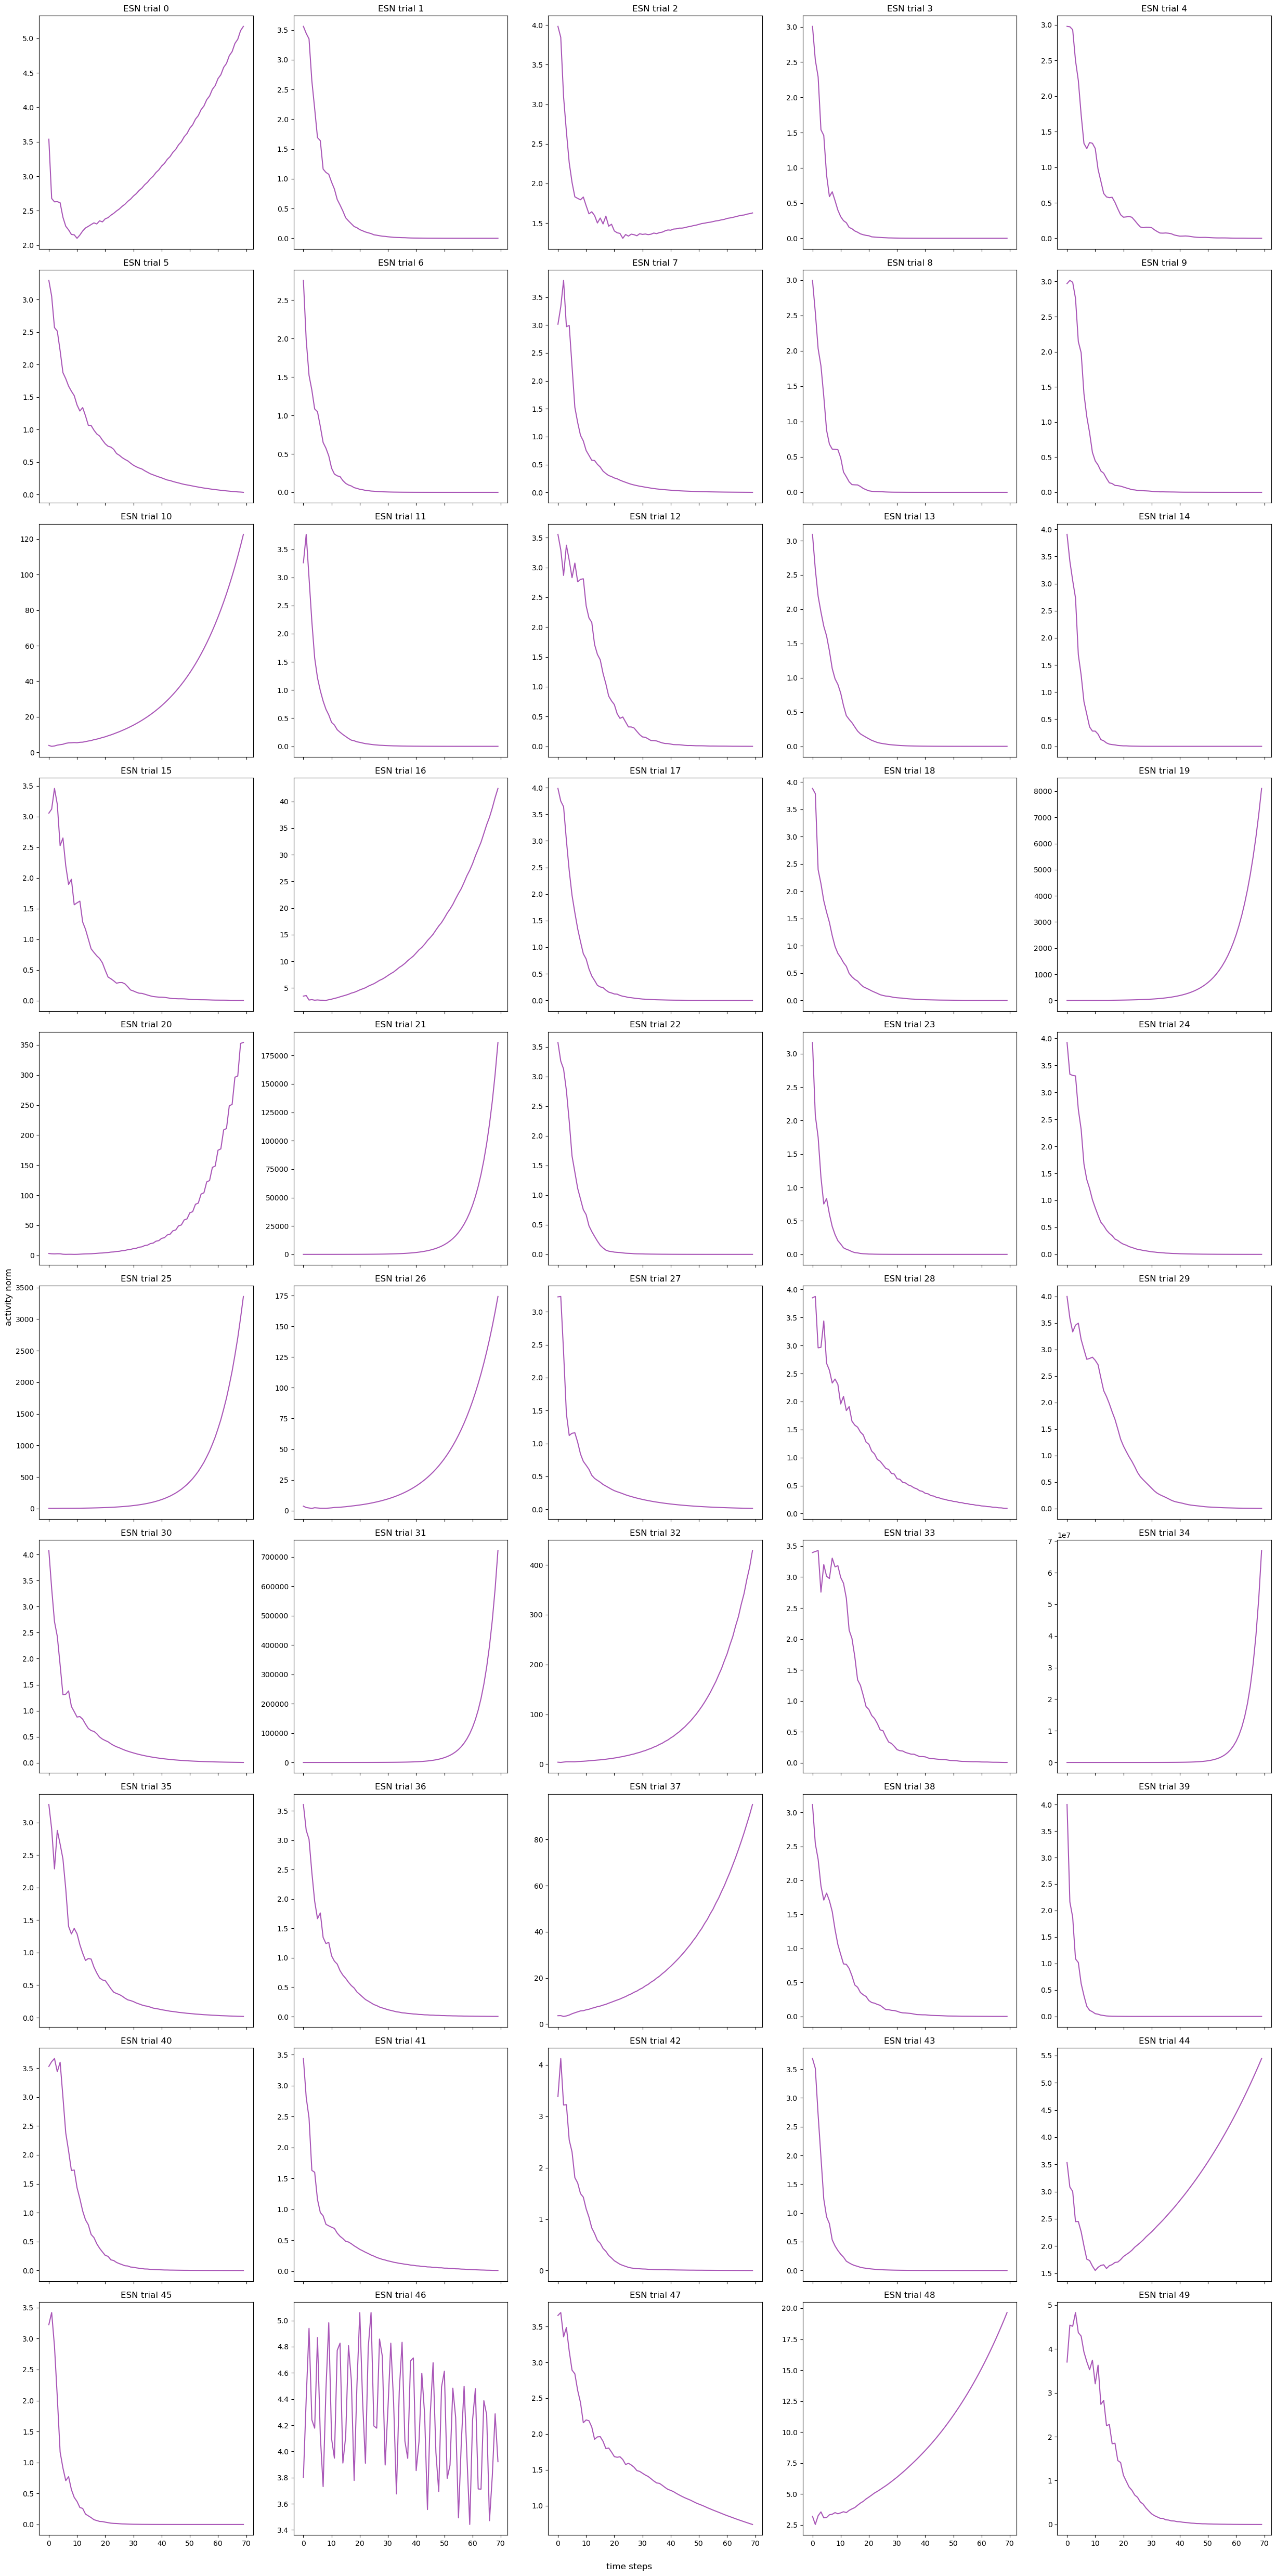

In [23]:
# plot the norms of the different weights
x_vals = np.arange(1,70)
fig, ax = plt.subplots(10,5, figsize=(25,50), sharex=True)
for t in range(50):
    #for i in range(Hippo_n_feature):
    ax[t//5, t%5].plot(neuron_norms_for_srs[t, :],c='#a956b7')
    ax[t//5, t%5].set_title(f'ESN trial {t}')
    #ax[t//5, t%5].scatter(thresh_crossed[t], 0, c='r')

fig.supxlabel("time steps")   
fig.supylabel("activity norm") 
fig.tight_layout(rect=[0.01, 0.01, 1, 1]) 


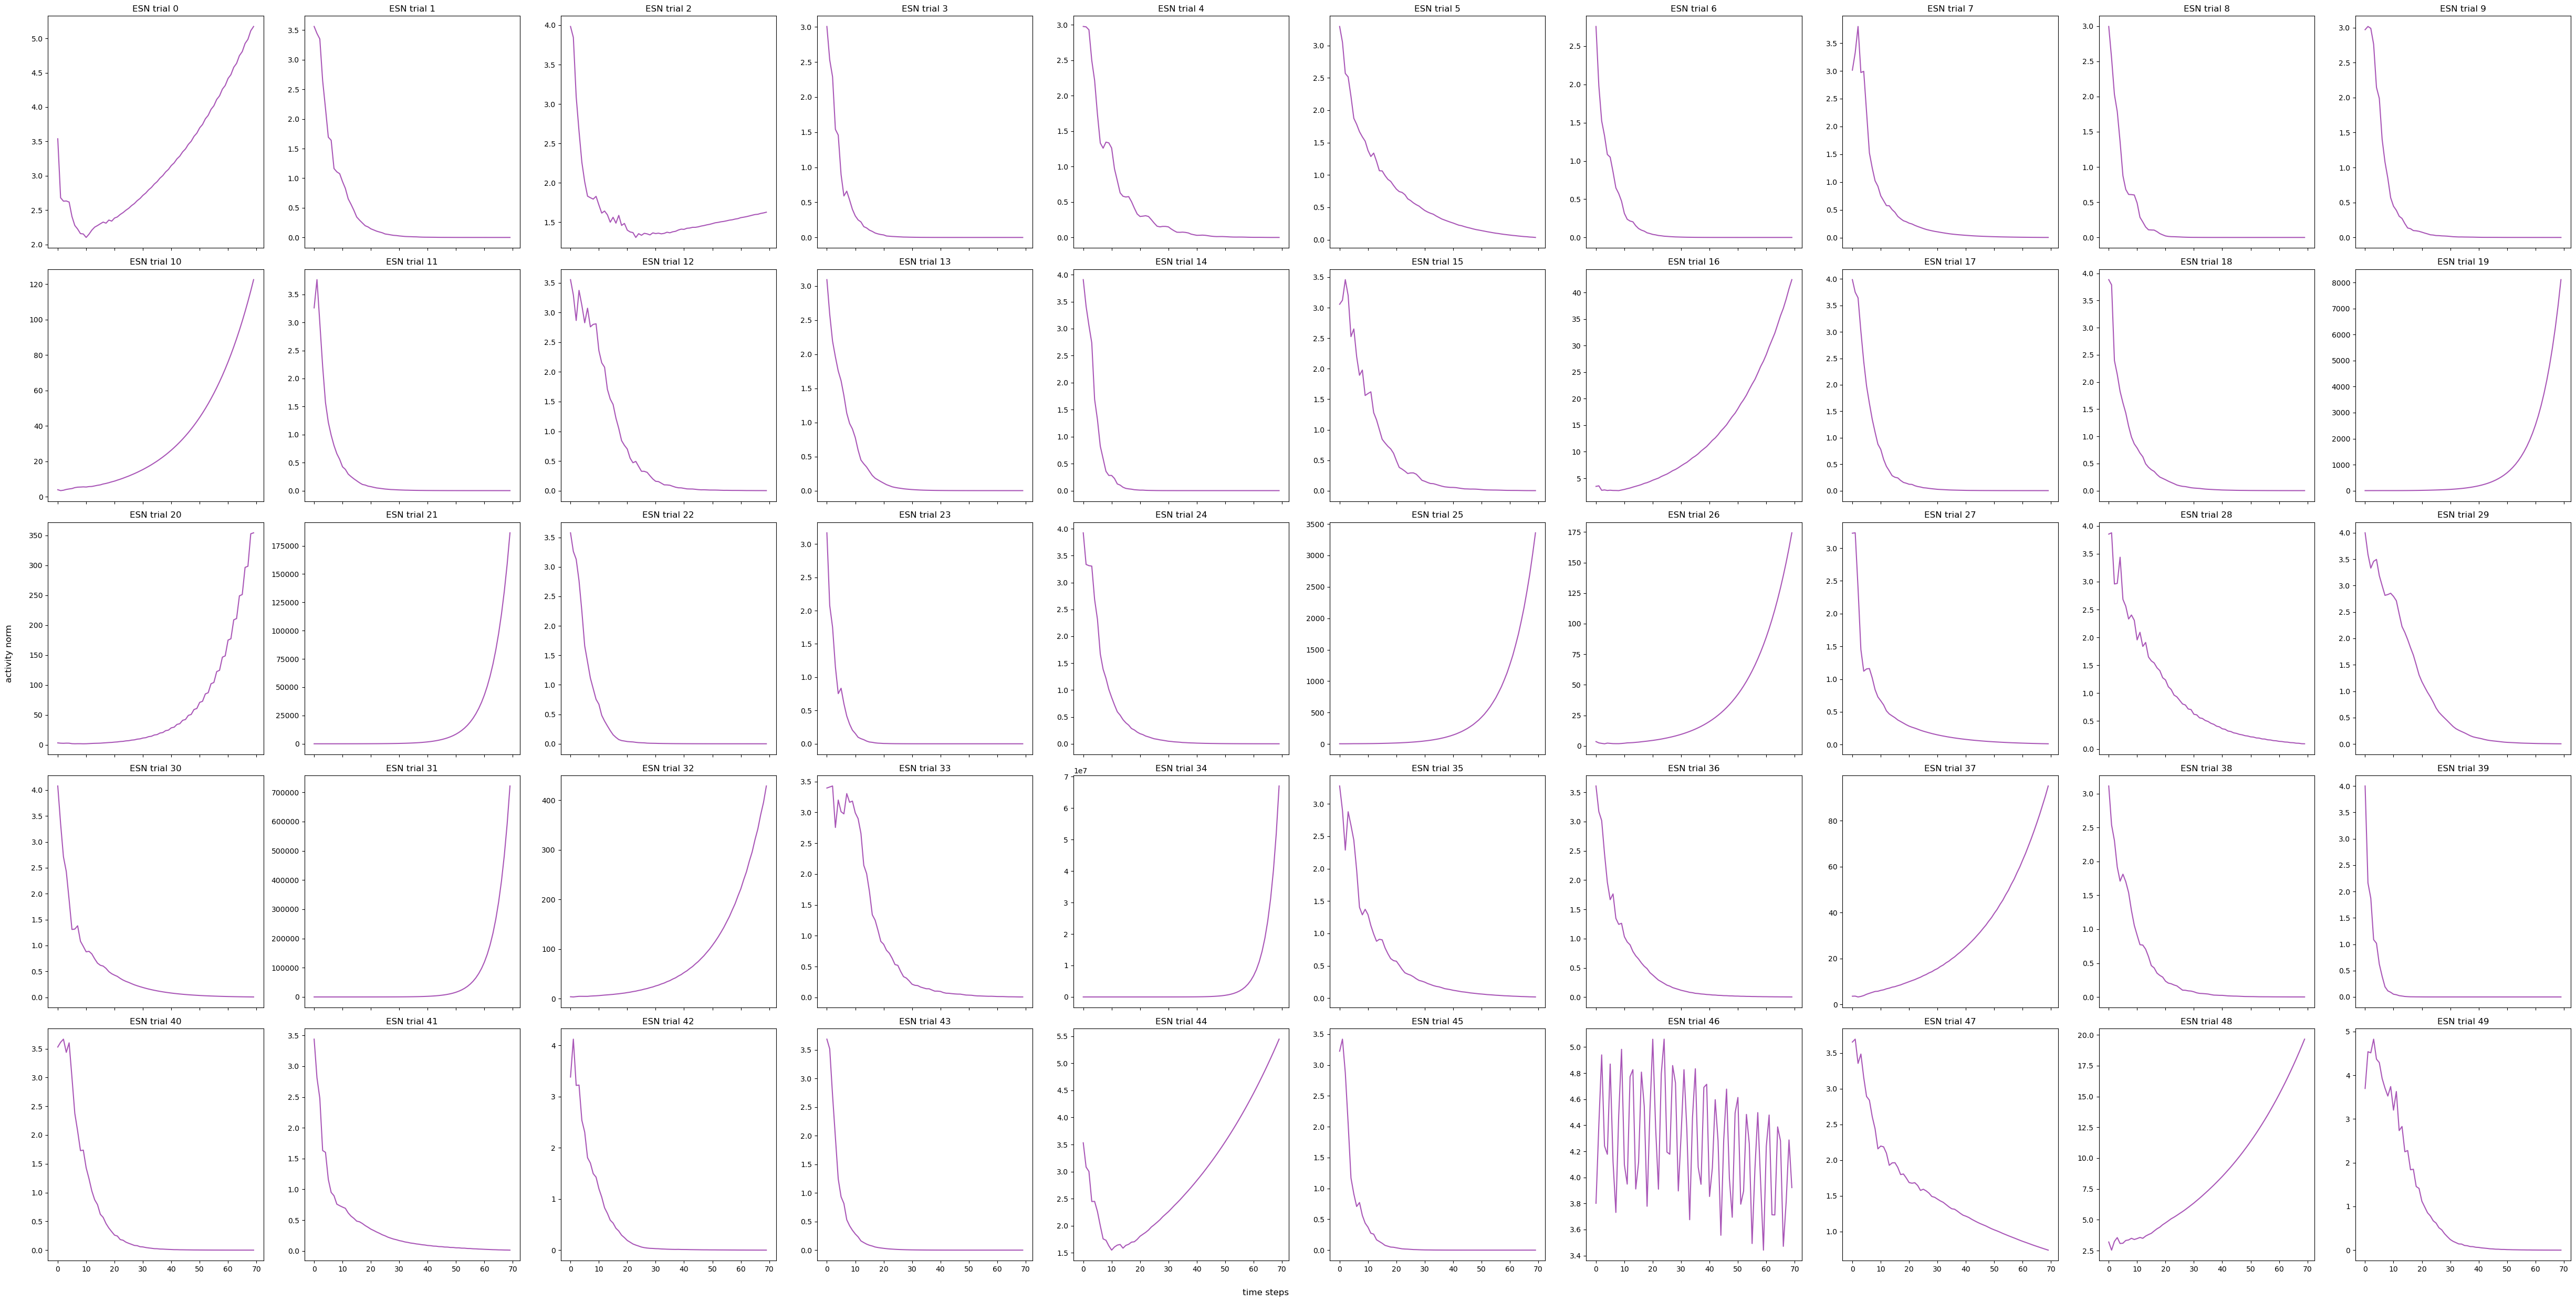

In [29]:
# plot the norms of the different weights
x_vals = np.arange(1,70)
fig, ax = plt.subplots(5,10, figsize=(50,25), sharex=True)
for t in range(50):
    #for i in range(Hippo_n_feature):
    ax[t//10, t%10].plot(neuron_norms_for_srs[t, :],c='#a956b7')
    ax[t//10, t%10].set_title(f'ESN trial {t}')
    #ax[t//5, t%5].scatter(thresh_crossed[t], 0, c='r')

fig.supxlabel("time steps")   
fig.supylabel("activity norm") 
fig.tight_layout(rect=[0.02, 0.01, 1, 1]) 
